In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

In [4]:
df=pd.read_csv(r"C:\Users\pc\Downloads\Prolect\android_games_eda_ready.csv")

In [5]:
df

,game_id,game_name,developer_name,package_name,genre,sub_genre,monetization_model,contains_ads,has_in_app_purchases,multiplayer_support,...,has_seasonal_event,cross_platform_available,cloud_save_support,is_hit_game,post_30d_revenue_usd,post_30d_rating_count,featured_duration_days,store_platform,country_code_primary,row_checksum_id
0,622,Game_622_Arena,Studio_205,com.studio1664.game622,Casual,Party Game,Freemium,Yes,Yes,NaN,...,False,True,True,0,9963.75,6328,NaN,Android,IN,CHK_100621
1,4386,Game_4386_Rush,Studio_923,com.studio1615.game4386,RPG,Idle RPG,Free,Yes,No,Online,...,False,True,False,0,17880.43,9346,NaN,Android,IN,CHK_104385
2,6795,Game_6795_Tycoon,Studio_921,com.studio44.game6795,RPG,Idle RPG,Free,Yes,No,NaN,...,True,False,False,0,6060.03,4096,7.0,Android,BR,CHK_106794
3,4563,Game_4563_Quest,Studio_1873,com.studio1353.game4563,Casual,Idle Clicker,Paid,No,Yes,NaN,...,False,False,False,0,816621.72,12402,NaN,Android,US,CHK_104562
4,9265,Game_9265_Legends,Studio_1608,com.studio1308.game9265,RPG,MMORPG,Free,Yes,No,NaN,...,True,False,True,0,159839.20,7517,NaN,Android,IN,CHK_109264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10145,5735,Game_5735_Legends,Studio_1081,com.studio774.game5735,Action,Endless Runner,Freemium,Yes,No,NaN,...,False,False,True,0,841316.57,156319,12.0,Android,IN,CHK_105734
10146,5192,Game_5192_Arena,Studio_1591,com.studio2181.game5192,RPG,Turn-Based,Free,Yes,Yes,NaN,...,False,True,False,0,172807.46,49521,NaN,Android,IN,CHK_105191
10147,5391,Game_5391_Tycoon,Studio_1105,com.studio1086.game5391,Sports,Cricket,Free,Yes,Yes,Online,...,False,True,True,0,43861.19,3539,NaN,Android,IN,CHK_105390
10148,861,Game_861_Legends,Studio_1864,com.studio1402.game861,Casual,Hypercasual,Free,Yes,No,NaN,...,False,False,False,0,6529.90,3189,NaN,Android,IN,CHK_100860


In [6]:
df.shape

(10150, 57)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10150 entries, 0 to 10149
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   game_id                   10150 non-null  int64  
 1   game_name                 10150 non-null  str    
 2   developer_name            10150 non-null  str    
 3   package_name              10150 non-null  str    
 4   genre                     10150 non-null  str    
 5   sub_genre                 10150 non-null  str    
 6   monetization_model        10150 non-null  str    
 7   contains_ads              10150 non-null  str    
 8   has_in_app_purchases      10150 non-null  str    
 9   multiplayer_support       6084 non-null   str    
 10  age_rating                10150 non-null  str    
 11  art_style                 10150 non-null  str    
 12  engine_used               10150 non-null  str    
 13  region_focus              10150 non-null  str    
 14  publisher_tier   

In [8]:
df.duplicated().sum()

np.int64(150)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

game_id                       int64
game_name                       str
developer_name                  str
package_name                    str
genre                           str
sub_genre                       str
monetization_model              str
contains_ads                    str
has_in_app_purchases            str
multiplayer_support             str
age_rating                      str
art_style                       str
engine_used                     str
region_focus                    str
publisher_tier                  str
event_theme                     str
release_date                    str
soft_launch_date                str
last_update_date                str
was_featured_on_store          bool
featured_start_date             str
featured_end_date               str
price_usd                   float64
downloads                     int64
retention_day1_pct          float64
retention_day7_pct          float64
retention_day30_pct         float64
active_users_30d            

In [12]:
df.isnull().sum()

game_id                        0
game_name                      0
developer_name                 0
package_name                   0
genre                          0
sub_genre                      0
monetization_model             0
contains_ads                   0
has_in_app_purchases           0
multiplayer_support         4013
age_rating                     0
art_style                      0
engine_used                    0
region_focus                   0
publisher_tier                 0
event_theme                 7577
release_date                   0
soft_launch_date            1000
last_update_date               0
was_featured_on_store          0
featured_start_date         6697
featured_end_date           6697
price_usd                      0
downloads                      0
retention_day1_pct             0
retention_day7_pct             0
retention_day30_pct            0
active_users_30d               0
avg_session_minutes            0
avg_daily_sessions             0
crash_rate

In [13]:
cat_cols=df.select_dtypes(include='object').columns
num_cols=df.select_dtypes(include=np.number).columns
df[cat_cols]=df[cat_cols].fillna('Unknown').astype(str)
df[num_cols]=df[num_cols].fillna(df[num_cols].median())

C:\Users\pc\AppData\Local\Temp\ipykernel_4456\1316290109.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include='object').columns


In [14]:
df.isnull().sum()

game_id                     0
game_name                   0
developer_name              0
package_name                0
genre                       0
sub_genre                   0
monetization_model          0
contains_ads                0
has_in_app_purchases        0
multiplayer_support         0
age_rating                  0
art_style                   0
engine_used                 0
region_focus                0
publisher_tier              0
event_theme                 0
release_date                0
soft_launch_date            0
last_update_date            0
was_featured_on_store       0
featured_start_date         0
featured_end_date           0
price_usd                   0
downloads                   0
retention_day1_pct          0
retention_day7_pct          0
retention_day30_pct         0
active_users_30d            0
avg_session_minutes         0
avg_daily_sessions          0
crash_rate_pct              0
apk_size_mb                 0
update_frequency_days       0
rating_avg

In [15]:
df['is_hit_game'].unique()

array([0, 1])

In [16]:
df['is_hit_game'].value_counts()

is_hit_game
0    9800
1     200
Name: count, dtype: int64

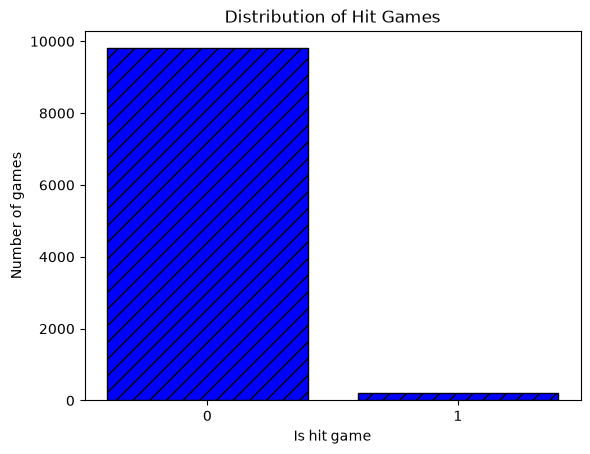

In [17]:
plt.bar(['0','1'], [9800,200],color='red',facecolor='blue',edgecolor='black',hatch='//')
plt.title('Distribution of Hit Games')
plt.xlabel('Is hit game')
plt.ylabel('Number of games')
plt.show()

In [18]:
corr=df.corr(numeric_only=True)

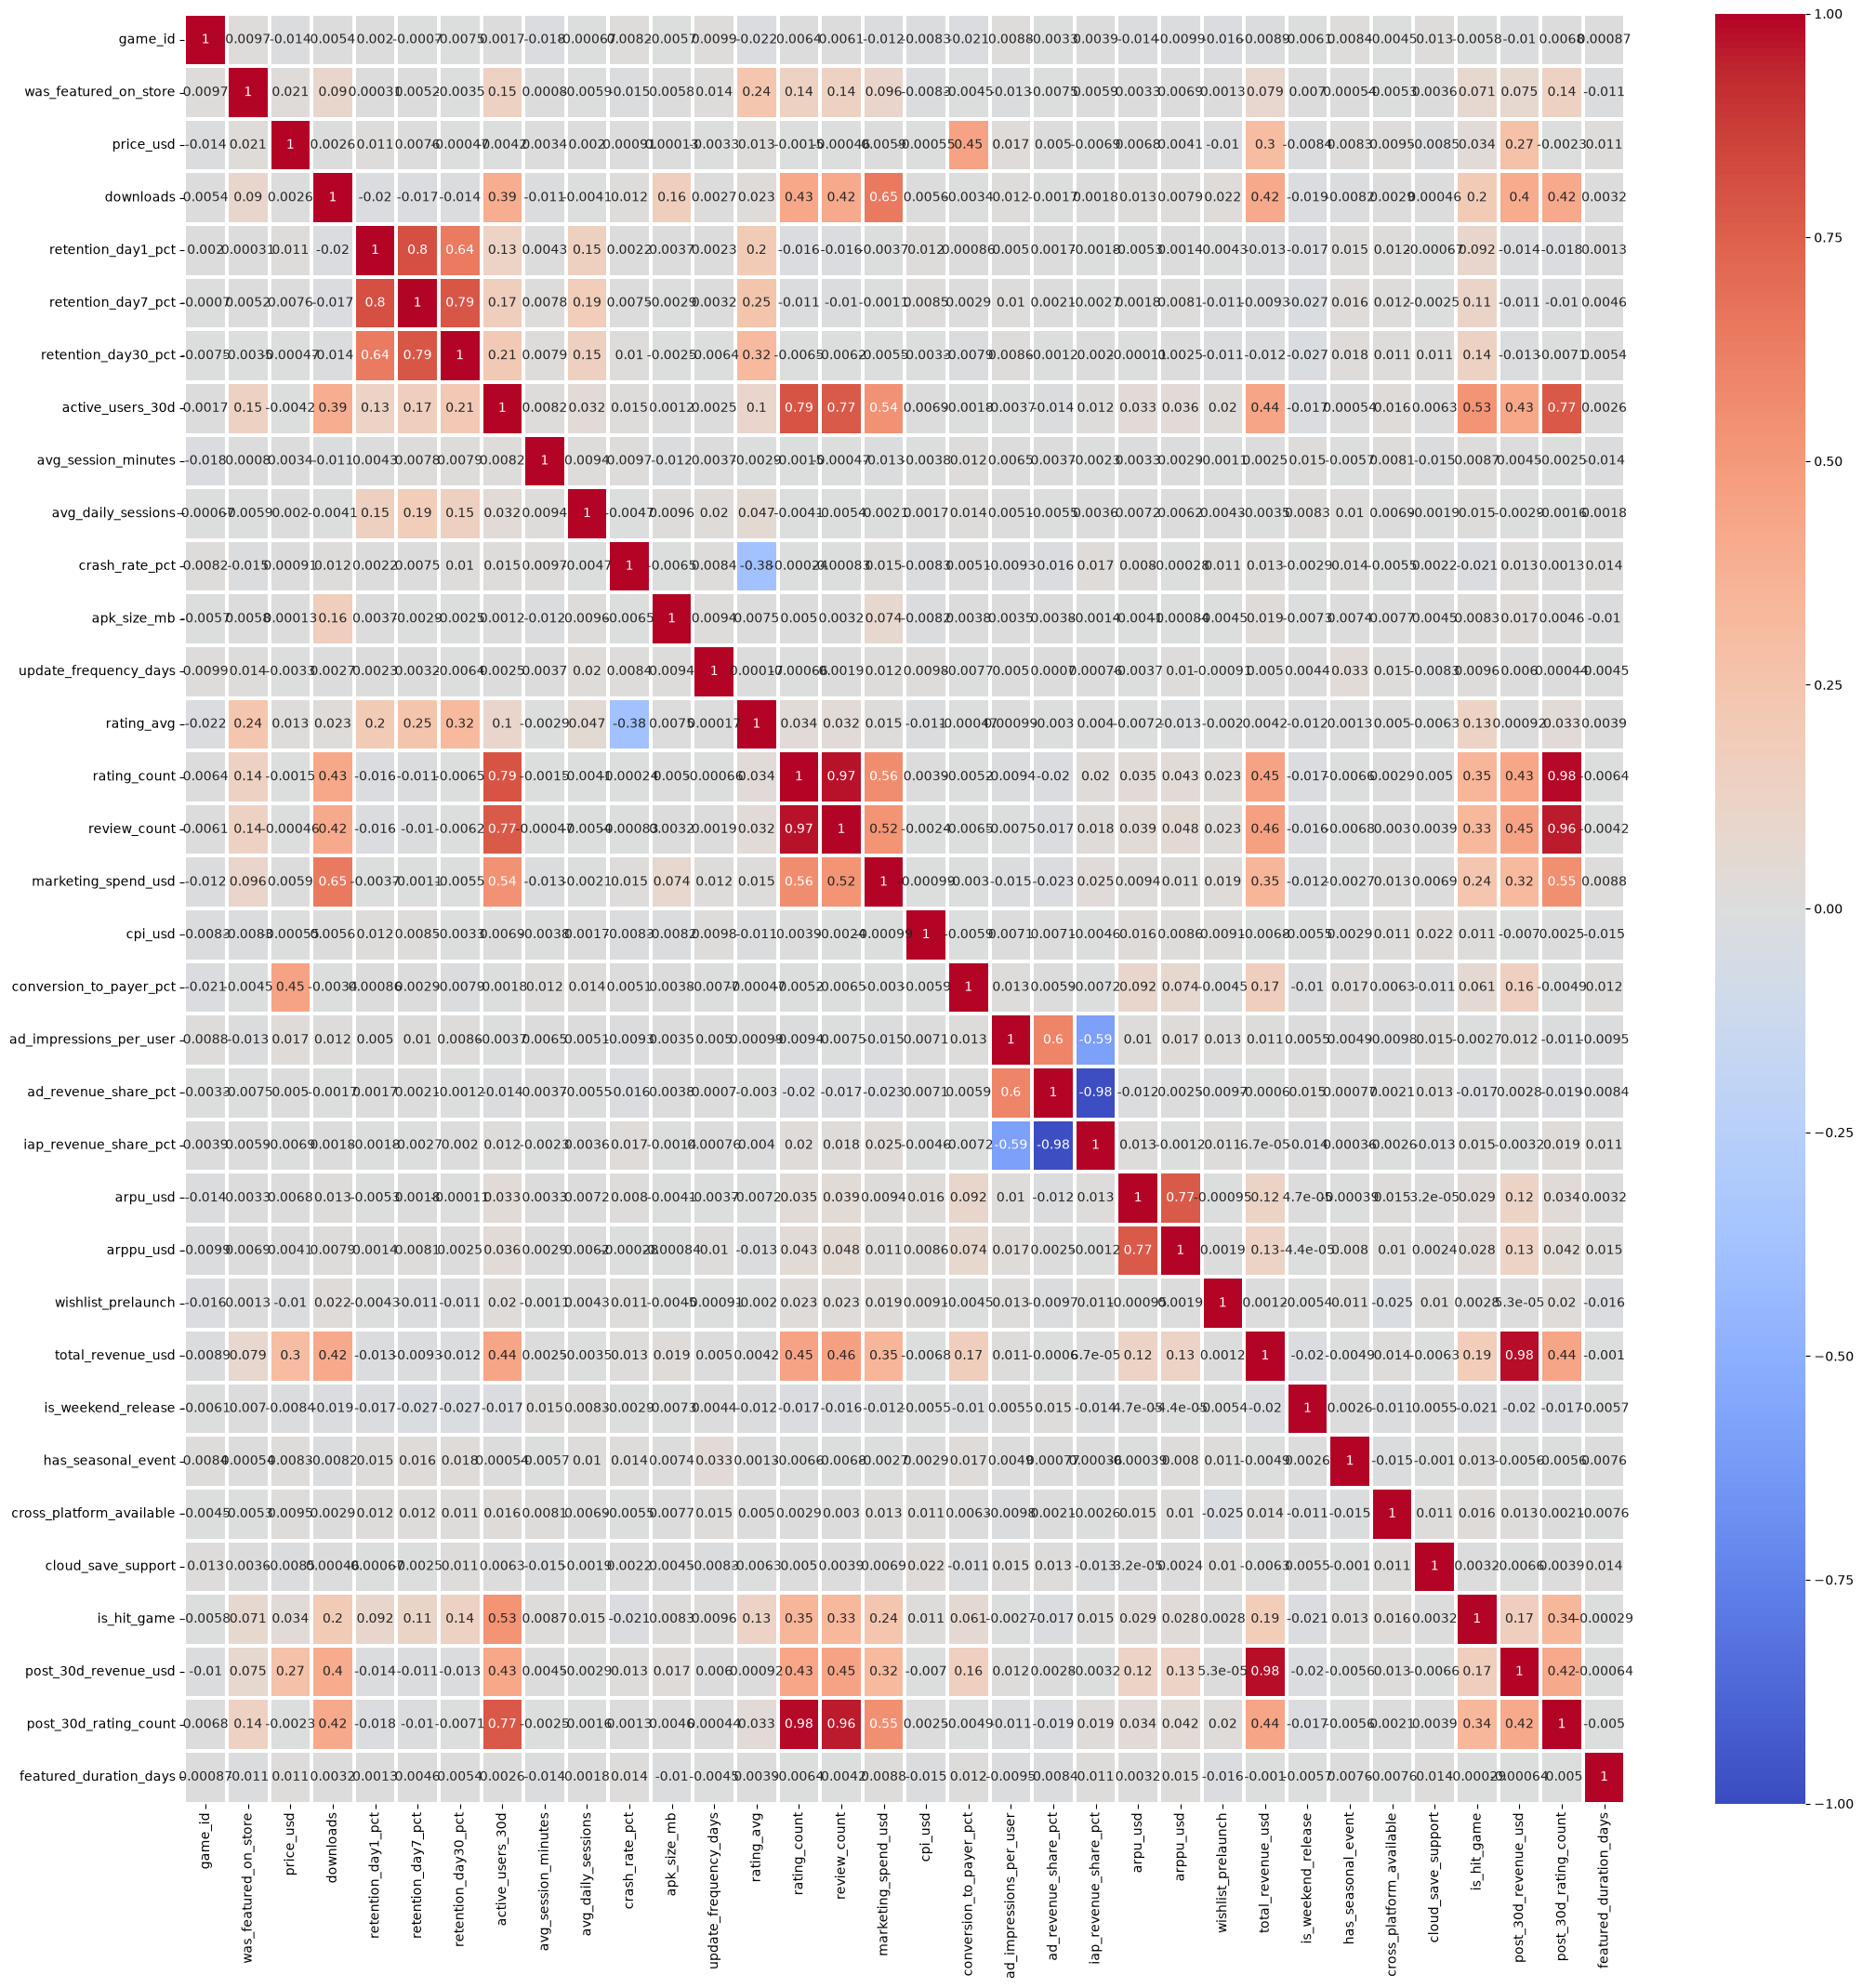

In [19]:
plt.figure(figsize=(25,25))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm", linewidth=1.5)
plt.show()

In [20]:
cols_to_drop = [
    'game_id', 'game_name', 'package_name', 'developer_name',
    'release_date', 'soft_launch_date', 'last_update_date',
    'featured_start_date', 'featured_end_date', 'row_checksum_id'
]
df_prep = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

In [21]:
df.shape

(10000, 57)

In [22]:
x=df_prep.drop(columns=['is_hit_game'])
y=df_prep['is_hit_game']

In [23]:
x_encoded=pd.get_dummies(x,drop_first=True)

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x_encoded,y,test_size=0.2,random_state=42,stratify=y)

In [25]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [26]:
print(f"Encoded features count: {x_encoded.shape[1]}")
print(f"Training set size: {x_train.shape[0]} samples")
print(f"Testing set size: {x_test.shape[0]} samples")

Encoded features count: 101
Training set size: 8000 samples
Testing set size: 2000 samples


In [27]:
pca=PCA(n_components=0.95,random_state=42)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)

In [28]:
print(f"Original feature dimensions: {x_train_scaled.shape[1]}")
print(f"Reduced PCA feature dimensions: {x_train_pca.shape[1]}")

Original feature dimensions: 101
Reduced PCA feature dimensions: 71


In [29]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)
y_pred_knn=knn_model.predict(x_test_scaled)

In [30]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1960
           1       0.75      0.07      0.14        40

    accuracy                           0.98      2000
   macro avg       0.87      0.54      0.56      2000
weighted avg       0.98      0.98      0.97      2000



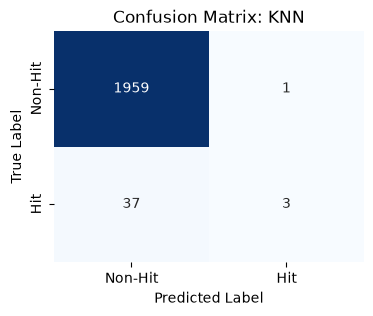

In [31]:
cm_knn=confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.title('Confusion Matrix: KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [32]:
dt_model=DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt_model.fit(x_train_scaled, y_train)
y_pred_dt=dt_model.predict(x_test_scaled)

In [33]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1960
           1       0.97      0.95      0.96        40

    accuracy                           1.00      2000
   macro avg       0.99      0.97      0.98      2000
weighted avg       1.00      1.00      1.00      2000



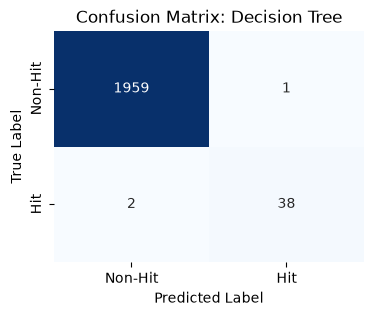

In [34]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [35]:
nb_model=GaussianNB()
nb_model.fit(x_train_pca, y_train)
y_pred_nb=nb_model.predict(x_test_pca)

In [36]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1960
           1       0.34      0.30      0.32        40

    accuracy                           0.97      2000
   macro avg       0.66      0.64      0.65      2000
weighted avg       0.97      0.97      0.97      2000



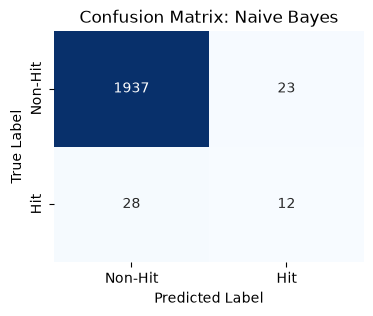

In [37]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.title('Confusion Matrix: Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [38]:
svm_model=SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(x_train_scaled, y_train)
y_pred_svm=svm_model.predict(x_test_scaled)

In [39]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1960
           1       0.69      0.55      0.61        40

    accuracy                           0.99      2000
   macro avg       0.84      0.77      0.80      2000
weighted avg       0.98      0.99      0.99      2000



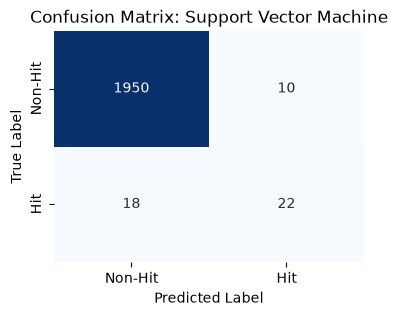

In [40]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.title('Confusion Matrix: Support Vector Machine')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [41]:
rf_model=RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(x_train_scaled, y_train)
y_pred_rf=rf_model.predict(x_test_scaled)

In [42]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1960
           1       0.76      0.80      0.78        40

    accuracy                           0.99      2000
   macro avg       0.88      0.90      0.89      2000
weighted avg       0.99      0.99      0.99      2000



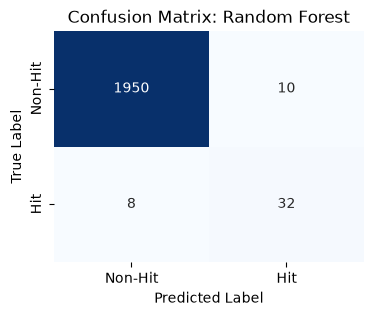

In [43]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [44]:
gb_model=GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
gb_model.fit(x_train_scaled, y_train)
y_pred_gb=gb_model.predict(x_test_scaled)

In [45]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1960
           1       1.00      0.82      0.90        40

    accuracy                           1.00      2000
   macro avg       1.00      0.91      0.95      2000
weighted avg       1.00      1.00      1.00      2000



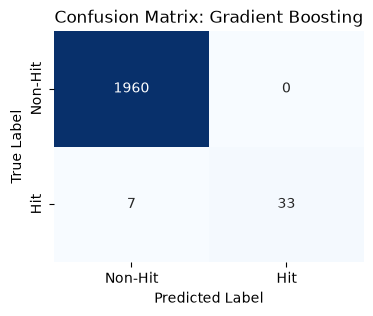

In [46]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.title('Confusion Matrix: Gradient Boosting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [47]:
from xgboost import XGBClassifier
xg_model=XGBClassifier(n_estimators=150,learning_rate=0.05,max_depth=3,max_leaves=5,random_state=42, scale_pos_weight=7000/200)
xg_model.fit(x_train_scaled, y_train)
y_pred_xg=xg_model.predict(x_test_scaled)

In [48]:
print(classification_report(y_test, y_pred_xg))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1960
           1       0.80      1.00      0.89        40

    accuracy                           0.99      2000
   macro avg       0.90      1.00      0.94      2000
weighted avg       1.00      0.99      1.00      2000



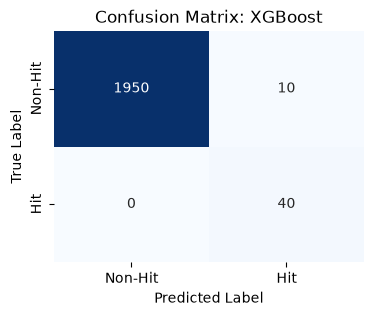

In [49]:
cm_xgb = confusion_matrix(y_test, y_pred_xg)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.title('Confusion Matrix: XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

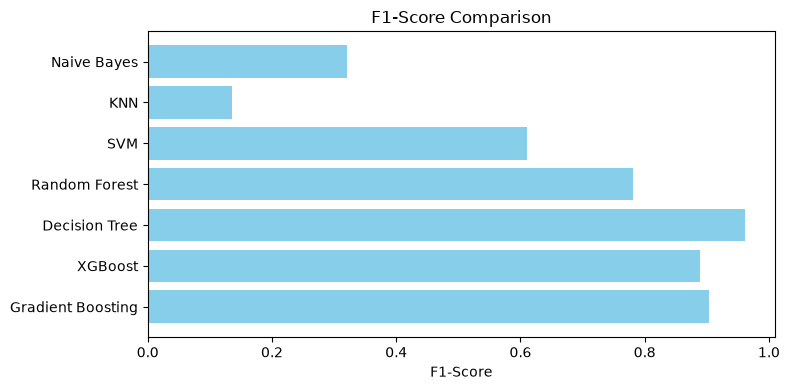

In [50]:
models={
    'Gradient Boosting': gb_model,
    'XGBoost': xg_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'SVM': svm_model,
    'KNN': knn_model,
    'Naive Bayes': nb_model
}
scores={}
for name, model in models.items():
    x_test_data=x_test_pca if name == 'Naive Bayes' else x_test_scaled
    preds=model.predict(x_test_data)
    scores[name]=f1_score(y_test, preds)
plt.figure(figsize=(8, 4))
plt.barh(list(scores.keys()), list(scores.values()), color='skyblue')
plt.title('F1-Score Comparison')
plt.xlabel('F1-Score')
plt.tight_layout()
plt.show()